<a href="https://colab.research.google.com/github/Loknath73/Skin-Cancer/blob/main/Skin_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os
import imghdr
import numpy as np
from matplotlib import pyplot as pyplot
import pandas as pd

/tmp/ipykernel_917/802866750.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
from google.colab import files
Train_Dataset = files.upload()
!unzip -q "archive (1).zip" -d train_data

Saving archive (1).zip to archive (1).zip


In [ ]:
from google.colab import files
Test_Dataset =files.upload()
!unzip -q "archive (1) (1).zip" -d test_data

Saving archive (1).zip to archive (1) (1).zip


In [ ]:
import os


print("Train data class folders:", os.listdir('train_data'))
print("Test data class folders:", os.listdir('test_data'))

Train data class folders: ['melanoma_cancer_dataset']
Test data class folders: ['melanoma_cancer_dataset']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32


TRAIN_DIR = 'train_data/melanoma_cancer_dataset/train'
TEST_DIR = 'test_data/melanoma_cancer_dataset/test'


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)


val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Found 7684 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.8375 - loss: 0.3749 - val_accuracy: 0.8574 - val_loss: 0.3205
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.8621 - loss: 0.3214 - val_accuracy: 0.8985 - val_loss: 0.2835
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.8630 - loss: 0.3092 - val_accuracy: 0.8522 - val_loss: 0.3236
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.8752 - loss: 0.2963 - val_accuracy: 0.8969 - val_loss: 0.2610
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.8770 - loss: 0.2886 - val_accuracy: 0.8829 - val_loss: 0.2766
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.8870 - loss: 0.2757 - val_accuracy: 0.8876 - val_loss: 0.2738
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/ste

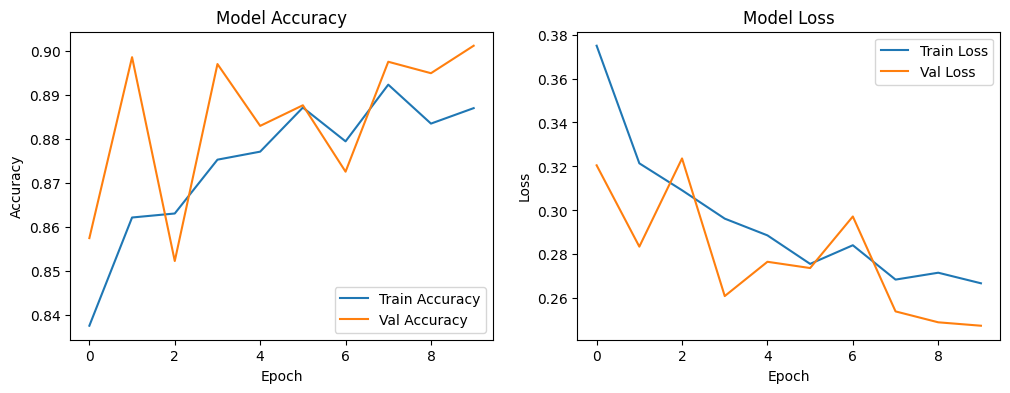

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:

test_loss, test_acc = model.evaluate(test_generator)
print(f"\n (Final Test Accuracy): {test_acc * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 738ms/step - accuracy: 0.9120 - loss: 0.2274

 (Final Test Accuracy): 91.20%


In [ ]:

model.save('skin_cancer_detector_model.h5')
print("Model saved successfully as 'skin_cancer_detector_model.h5'")

Model saved successfully as 'skin_cancer_detector_model.h5'


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['benign', 'malignant']))
print(confusion_matrix(y_true, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 831ms/step
              precision    recall  f1-score   support

      benign       0.89      0.93      0.91       500
   malignant       0.93      0.89      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

[[467  33]
 [ 55 445]]


In [19]:
import os

malignant_dir = 'test_data/melanoma_cancer_dataset/test/malignant'
sample_files = os.listdir(malignant_dir)[:15]

for f in sample_files:
    predict_skin_mole(os.path.join(malignant_dir, f))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
----------------------------------------
Prediction: MALIGNANT (Cancerous Mole Detected)
Confidence Score: 100.00%
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
----------------------------------------
Prediction: MALIGNANT (Cancerous Mole Detected)
Confidence Score: 99.90%
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
----------------------------------------
Prediction: MALIGNANT (Cancerous Mole Detected)
Confidence Score: 100.00%
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
----------------------------------------
Prediction: MALIGNANT (Cancerous Mole Detected)
Confidence Score: 96.67%
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
----------------------------------------
Prediction: MALIGNANT (Cancerous Mole Detected)
Confidence Score: 78.04%
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/